# NHR Workshop on Practical Quantum Computing 2026 - Interactive Coding Session 2

# Circuits, Hybrid Workflows and VQE

## Importing software packages

In [36]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import qiskit

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector

from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

%matplotlib inline

In [37]:
print("Python:", sys.version)
print("Executable:", sys.executable)
print("Qiskit version:", qiskit.__version__)

Python: 3.10.20 | packaged by conda-forge | (main, Mar  5 2026, 16:42:22) [GCC 14.3.0]
Executable: /home/sacvj/miniconda3/envs/quantum-workshop/bin/python
Qiskit version: 2.4.1


## Quantum circuits and entanglement

In the last coding session, we looked at single-qubit operations, and briefly discussed a very short two-qubit circuit, where we created a *Bell state*.

Now, we are going to have a look at more complex quantum circuits, which are the basis of practical quantum computing. 

As a first example, we will create a five-qubit GHZ state, which is simular to the Bell state, and look at how one represents circuits schematically.

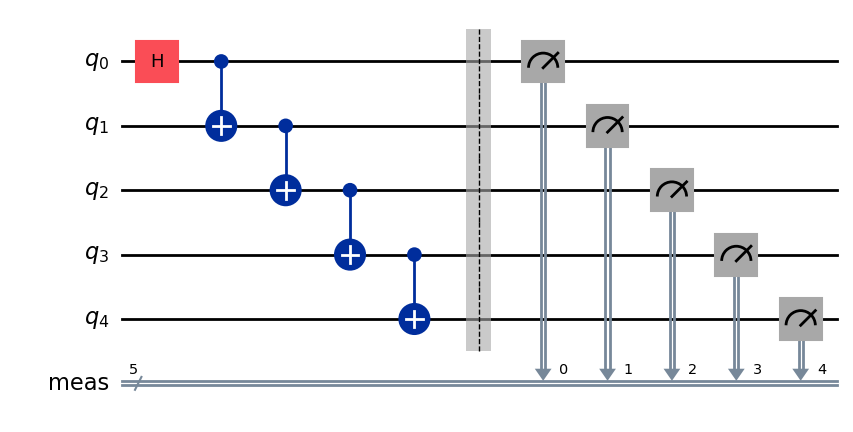

In [38]:
qc = QuantumCircuit(5)

qc.h(0)
for i in range(4):
    qc.cx(i, i+1)
qc.measure_all()

qc.draw("mpl")
plt.show()

The most crucial part in this circuit, and also in the two-qubit Bell state from the previous Notebook, is the $CX$ gate. 

The $CX$ gate is a conditional two-qubit gate. It performs an $X$ gate on the *target* qubit, if the *control* qubit is in state $\ket{1}$. Therefore, the state of the target qubit now depends on the state of the control qubit. 

However, as we discussed, before measurement, the control qubit is generally not either in state $\ket{1}$ or not, it is in a superposition of $\ket{0}$ and $\ket{1}$. This means that the action of the $CX$ gate must be applied to a superposition of both possibilities at the same time. As a result, the two qubits can no longer be described independently.

Instead, the quantum state becomes a joint state of both qubits, where only the combined system has a well-defined description.

This is what we call **entanglement**: the state of the individual qubits is no longer independent, and the full information is encoded in the correlations between them rather than in the separate qubits themselves.

The above circuit uses $CX$ gates to create a five-qubit GHZ state. The first qubit is brought into superposition via a Hadamard gate, and then the states of the other 4 qubits are entangled with it via conditional X gates.

The result is that when we measure the qubits, they all must have the same state, so in an ideal setting we only measure the states $\ket{00000}$ and $\ket{11111}$, as we can see in the cell below.

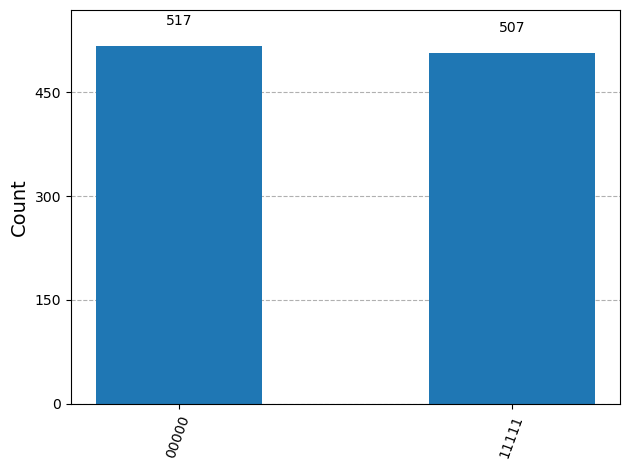

In [39]:
sim = AerSimulator()

job = sim.run(qc, shots=1024)
result = job.result()
counts = result.get_counts()

plt.close("all")
fig = plot_histogram(counts)
plt.show()

## Noise

So far we have simulated our circuit with the idealized AerSimulator. This means that initialization, gates and measurement are represented by exact mathematical operations with no imperfections. We can see this in the measurement plots, where no outlier states like $\ket{00100}$ or $\ket{10111}$ are measured. The randomness in the measurement frequencies of the states is due to intrinsically probabilistic nature of the measurement process in quantum mechanics.

However, no real quantum computer behaves like this. Real qubits suffer from unwanted interactions with their environment, thermal relaxation errors, different states evolving differently under the time-dependent Schrödinger equation, etc. 

Many different types of noise can be simulated with so-called *noise models*. In the following cell we will add a noise model to the AerSimulator and examine how the results change.

In [40]:
from qiskit_aer.noise import NoiseModel, depolarizing_error

noise_model = NoiseModel()

# single-qubit noise (after each gate)
error_1q = depolarizing_error(param=0.01, num_qubits=1)
noise_model.add_all_qubit_quantum_error(error_1q, ['rx', 'ry', 'h'])

# two-qubit noise (important!)
error_2q = depolarizing_error(param=0.05, num_qubits=2)
noise_model.add_all_qubit_quantum_error(error_2q, ['cx'])

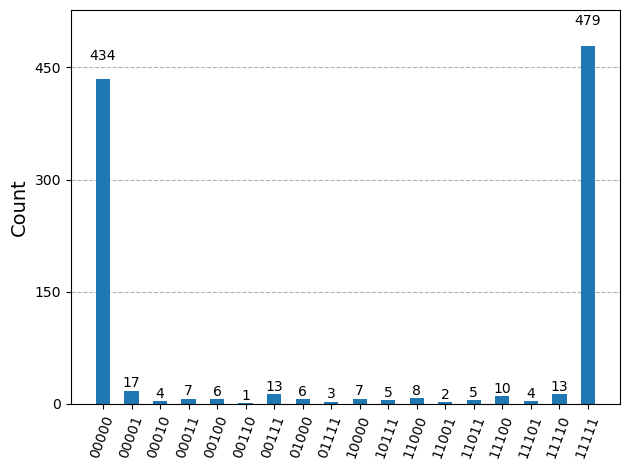

In [41]:
sim_noise = AerSimulator(noise_model=noise_model)

qc_m = qc.copy()

result_noisy = sim_noise.run(qc_m, shots=1024).result()
counts_noisy = result_noisy.get_counts()

plt.close("all")
fig = plot_histogram(counts_noisy)
plt.show()

In the cell above we added a model for depolarizing noise, that adds a random error to single-qubit and two-qubit gates in our circuit with adjustable probabilities (1% for single-qubit gates and 5% for two-qubit gates in this case). 

Even this very simple noise model already causes additional, unwanted measurement outcomes to appear. In practice, noise models can be made much more sophisticated in order to more accurately capture the characteristic error characteristics of real quantum hardware.

Next, we will look at a simple case of a real, practical quantum algorithm, and see how crucial error handling becomes for real-world applications.

## VQE - The Variational Quantum Eigensolver

The Variational Quantum Eigensolver combines quantum computing and classical optimization. The goal is to find a quantum state, that minimizes/maximizes a given loss function.

The approach is to represent the desired quantum state through the qubits of our (simulated) quantum computer. In order to perform classical optimization to find a good solution, the desired quantum state is prepared via a parametrized quantum circuit, which will be explained below.

First, we need to define the **loss function**, which in this case we want to minimize. Usually the loss function is defined as a *Hamiltonian* consisting of so-called *Pauli operators*. These Pauli operators correspond to the measurement of our qubits in different bases. 

For simplicity, we will only use measurements in the computational basis, which we are already familiar with, i.e. the measurement basis which has the eigenstates $\ket{0}$ and $\ket{1}$. 

We will use the following condensed matter physics-inspired Hamiltonian as our loss function: 

$H = Z_0 Z_1 + Z_1 Z_2 + Z_2 Z_3 - 0.5 (Z_0 - Z_1 + Z_2 - Z_3)$

Here, the $Z_i$ terms basically represents the outcome of measuring the $i$-th qubit's "spin", where we map the $\ket{0}$ state to the -1 spin state, and the $\ket{1}$ state to the +1 spin state. (Our VQE algorithm therefore can be interpreted as finding the ground state of a toy Ising spin model.)

In [19]:
from qiskit.quantum_info import SparsePauliOp

H = SparsePauliOp.from_list([
    ("ZZII", 1.0),
    ("IZZI", 1.0),
    ("IIZZ", 1.0),
    ("ZIII", -0.5),
    ("IZII",  0.5),
    ("IIZI", -0.5),
    ("IIIZ",  0.5),
])

Next, we define a so-called **circuit ansatz**, which defines the structure of the circuit we use to prepare the quantum state that is supposed to solve our optimization problem.

Our ansatz will simply be a four-qubit circuit, where a $R_y(\theta)$ gate is applied to every qubit, and at the end all four qubits are entangled via $CX$ gates. The VQE algorithm then aims to find the set of parameters, in this case the four rotation angles of the $R_y(\theta)$ gates, that produce a final quantum state that minimizes the loss Hamiltonian.

In [20]:
def ansatz(params):
    qc = QuantumCircuit(4)

    for i in range(4):
        qc.ry(params[i], i)

    qc.cx(0,1)
    qc.cx(1,2)
    qc.cx(2,3)

    return qc

Finally, we bring everything together by defining a function that takes the parameters as input, constructs the quantum circuit, and calculates the energy from it. In this case, we calculate the loss function (the energy) analytically from the state vector that our ansatz circuit produces.

In [21]:
def energy(params):
    qc = ansatz(params)
    state = Statevector.from_instruction(qc)
    return np.real(state.expectation_value(H))

In the following cell, we load one of Qiskits optimizer modules and perform the optimization, and show the result, i.e. our minimized energy and the set of parameters that produced it,

Final energy: -4.999999828829369
Optimal params: [3.14143    3.14168356 3.14146848 3.14119438]


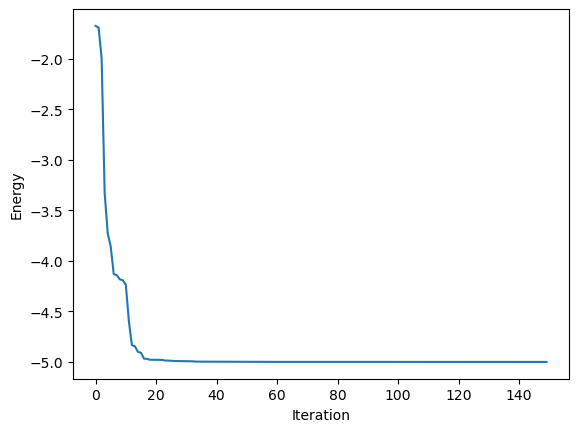

In [22]:
from qiskit_algorithms.optimizers import SPSA

# create an optimizer that also tracks the loss/energy history
loss_history = []

def callback(nfevs, x, fx, stepsize, accepted):
    loss_history.append(fx)

optimizer = SPSA(maxiter=150, callback=callback)

# optimization
init_params = np.random.uniform(0, 2*np.pi, 4)

result = optimizer.minimize(
    fun=energy,
    x0=init_params
)

print("Final energy:", result.fun)
print("Optimal params:", result.x)
plt.plot(loss_history)
plt.ylabel("Energy")
plt.xlabel("Iteration")
plt.show()

We can visualize the circuit that solved our optimization problem:

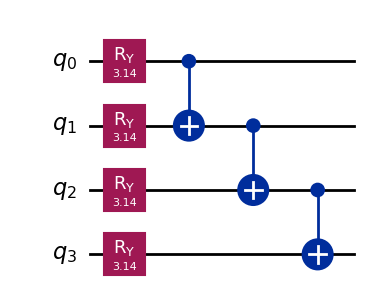

In [23]:
qc = ansatz(result.x)
qc.draw("mpl")
plt.show()

We chose a very simple Hamiltonian for simplicity, and the solution is rather trivial. The solution is simply a spin chain where neighboring spins are oppositely aligned. Also, importantly, the solution quantum state is not an entangled state, and can be represented via 4 separate Bloch spheres. **Note that this is not possible for general solutions with entanglement!**

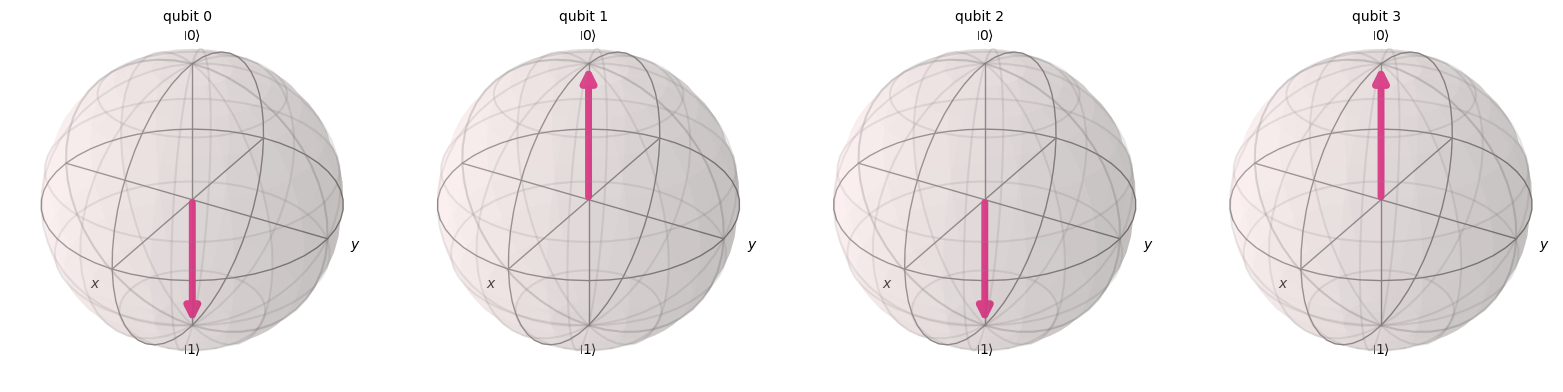

In [24]:
from qiskit.visualization import plot_bloch_multivector, plot_histogram

qc_final = ansatz(result.x)
state_final = Statevector.from_instruction(qc_final)

plot_bloch_multivector(state_final)
plt.show()

Simulating the solution circuit with the idealized AerSimulator results in only measuring the $\ket{0101}$ state.

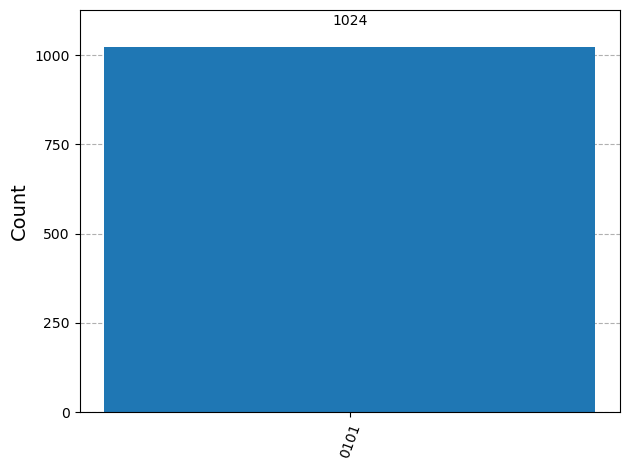

In [25]:
qc_meas = qc_final.copy()
qc_meas.measure_all()

sim = AerSimulator()
counts = sim.run(qc_meas, shots=1024).result().get_counts()

plot_histogram(counts)

plt.show()

## VQE with noise

In [26]:
noise_model = NoiseModel()

noise_model.add_all_qubit_quantum_error(
    depolarizing_error(param=0.02, num_qubits=1), ["h", "ry"]
)

noise_model.add_all_qubit_quantum_error(
    depolarizing_error(param=0.05, num_qubits=2), ["cx"]
)

noisy_sim = AerSimulator(noise_model=noise_model)

In [27]:
def z_energy(bitstring):
    z = np.array([1 - 2*int(b) for b in bitstring[::-1]])
    
    return (
        z[0]*z[1] +
        z[1]*z[2] +
        z[2]*z[3] -
        0.5*(z[0] - z[1] + z[2] - z[3])
    )

In [28]:
def noisy_energy(params):
    qc = ansatz(params)
    qc.measure_all()

    result = noisy_sim.run(qc, shots=1024).result()
    counts = result.get_counts()

    shots = sum(counts.values())

    E = 0
    for bitstring, c in counts.items():
        E += (c/shots) * z_energy(bitstring)

    return E

Noisy VQE energy: -4.337890625
Optimal params: [0.01192108 3.13591531 3.11848776 3.16234514]


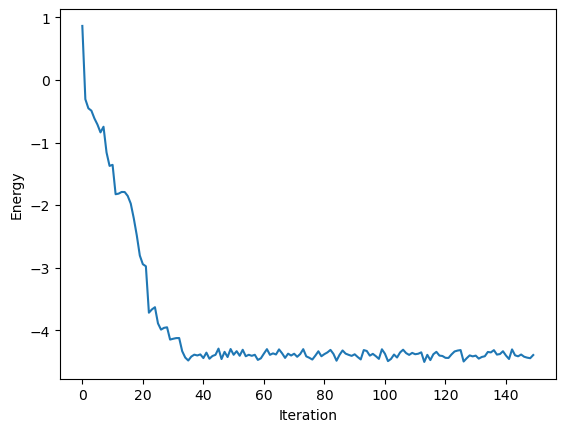

In [29]:
noisy_loss_history = []

def noisy_callback(nfevs, x, fx, stepsize, accepted):
    noisy_loss_history.append(fx)

noisy_optimizer = SPSA(maxiter=150, callback=noisy_callback)

init = np.random.uniform(0, 2*np.pi, 4)

noisy_result = noisy_optimizer.minimize(
    fun=noisy_energy,
    x0=init
)

print("Noisy VQE energy:", noisy_result.fun)
print("Optimal params:", noisy_result.x)
plt.plot(noisy_loss_history)
plt.ylabel("Energy")
plt.xlabel("Iteration")
plt.show()

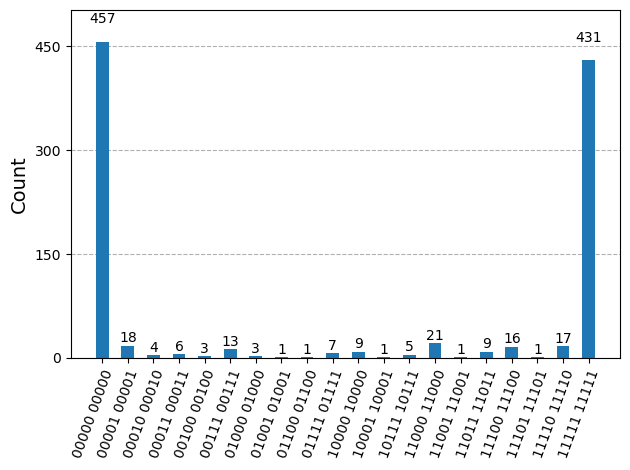

In [42]:
noisy_qc_meas = qc.copy()
noisy_qc_meas.measure_all()

noisy_counts = noisy_sim.run(noisy_qc_meas, shots=1024).result().get_counts()

plot_histogram(noisy_counts)

plt.show()

## EXERCISE 2:

Think about why the noise level can make VQE impractical. Think of a metric to quantify how "bad" the results are, and try to plot this quality of the results vs. different levels of noise.

**Bonus**: You can define more complex ansätze and look at how much worse the quality becomes even for small levels of noise! You can of course implement your own energy functions as well.

Noisy VQE energy: -3.064453125
Optimal params: [6.24311492 3.1864422  3.12645749 3.13012826]


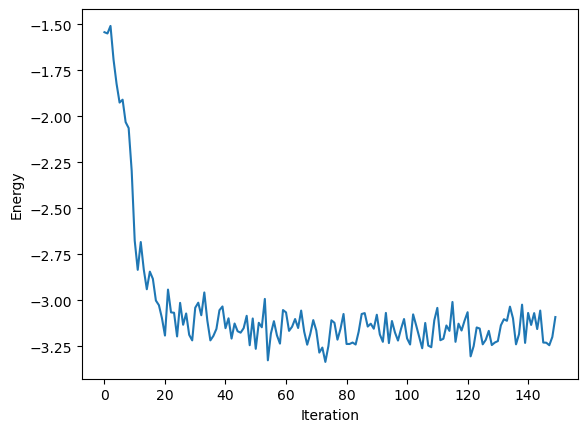

Noisy VQE energy: -1.720703125
Optimal params: [3.1155485  6.27444915 3.15980226 9.41396076]


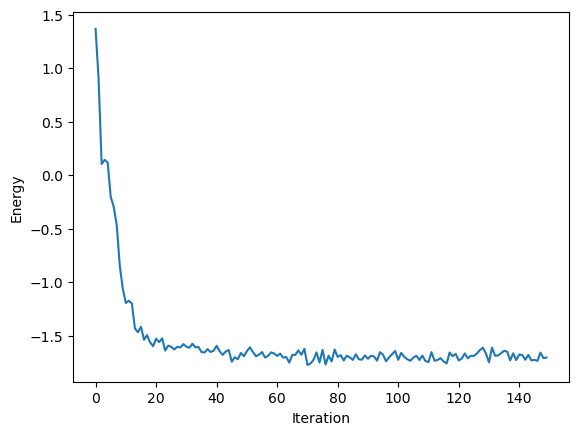

Noisy VQE energy: -2.2353515625
Optimal params: [6.53328727 3.17864734 3.16588023 2.94612923]


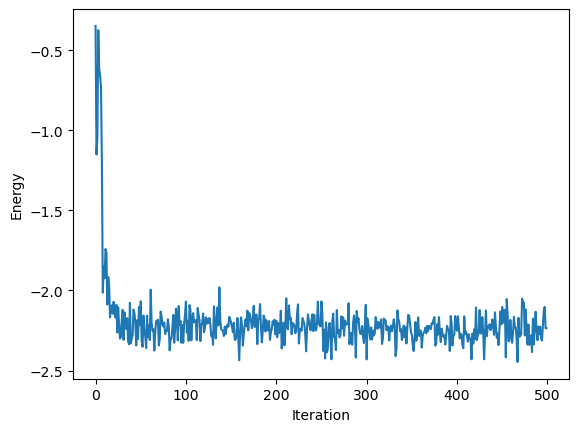

In [47]:
noisy_loss_history = []


noisy_optimizer = SPSA(maxiter=150, callback=noisy_callback)

init = np.random.uniform(0, 2*np.pi, 4)

noisy_result = noisy_optimizer.minimize(
    fun=noisy_energy,
    x0=init
)

print("Noisy VQE energy:", noisy_result.fun)
print("Optimal params:", noisy_result.x)
plt.plot(noisy_loss_history)
plt.ylabel("Energy")
plt.xlabel("Iteration")
plt.show()

noise_model = NoiseModel()

noise_model.add_all_qubit_quantum_error(
    depolarizing_error(param=0.02, num_qubits=1), ["h", "ry"]
)

noise_model.add_all_qubit_quantum_error(
    depolarizing_error(param=0.05, num_qubits=2), ["cx"]
)

noisy_sim = AerSimulator(noise_model=noise_model)

noisy_loss_history = []


noisy_optimizer = SPSA(maxiter=150, callback=noisy_callback)

init = np.random.uniform(0, 2*np.pi, 4)

noisy_result = noisy_optimizer.minimize(
    fun=noisy_energy,
    x0=init
)

print("Noisy VQE energy:", noisy_result.fun)
print("Optimal params:", noisy_result.x)
plt.plot(noisy_loss_history)
plt.ylabel("Energy")
plt.xlabel("Iteration")
plt.show()

noise_model = NoiseModel()

noise_model.add_all_qubit_quantum_error(
    depolarizing_error(param=0.30, num_qubits=1), ["h", "ry"]
)

noise_model.add_all_qubit_quantum_error(
    depolarizing_error(param=0.15, num_qubits=2), ["cx"]
)

noisy_sim = AerSimulator(noise_model=noise_model)

noisy_loss_history = []


noisy_optimizer = SPSA(maxiter=500, callback=noisy_callback)

init = np.random.uniform(0, 2*np.pi, 4)

noisy_result = noisy_optimizer.minimize(
    fun=noisy_energy,
    x0=init
)

print("Noisy VQE energy:", noisy_result.fun)
print("Optimal params:", noisy_result.x)
plt.plot(noisy_loss_history)
plt.ylabel("Energy")
plt.xlabel("Iteration")
plt.show()

In [49]:
!pip install qiskit_optimization

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.0/664.0 kB 16.3 MB/s  0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 19.5 MB/s  0:00:00
  Created wheel for docplex: filename=docplex-2.32.264-py3-none-any.whl size=703859 sha256=00ee61d54a5409b6281fe63a559924c9e60749d527177c61404ce4ebfff3be74
  Stored in directory: /home/sacvj/.cache/pip/wheels/2b/11/97/575eaf92a0089297bd21762bb457b9c48bd158b30e24f6ebf9
Successfully built docplex
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [qiskit_optimization]skit_optimization]


In [60]:
from qiskit_optimization import QuadraticProgram
from qiskit_optimization.converters import QuadraticProgramToQubo
from qiskit_optimization.translators import from_ising

# --- Parâmetros ---
N = 899
l1, l2 = 5, 5   # número de bits de p e q

# bits livres: índices 1 até l-2 (MSB e LSB são fixos)
free_p = list(range(1, l1 - 1))  # [1, 2, 3]
free_q = list(range(1, l2 - 1))  # [1, 2, 3]

# --- Montar o QuadraticProgram ---
qp = QuadraticProgram()

for i in free_p:
    qp.binary_var(f'p{i}')
for j in free_q:
    qp.binary_var(f'q{j}')
for i in free_p:
    for j in free_q:
        qp.binary_var(f'z{i}{j}')

# --- Calcular N' (N menos os termos fixos) ---
# p = 2^(l1-1) + 1 + soma(2^i * pi)
# q = 2^(l2-1) + 1 + soma(2^j * qj)
fixed_p = 2**(l1-1) + 1   # 17
fixed_q = 2**(l2-1) + 1   # 17
N_prime = N - fixed_p * fixed_q  # 899 - 289 = 610

print(f"fixed_p={fixed_p}, fixed_q={fixed_q}, N'={N_prime}")

# --- Montar coeficientes da função objetivo ---
# pq expandido = fixed_p*fixed_q 
#              + fixed_p * soma(2^j qj)
#              + fixed_q * soma(2^i pi)
#              + soma_ij(2^i * 2^j * zij)
# Queremos: [fixed_p*soma(2^j qj) + fixed_q*soma(2^i pi) + soma(2^(i+j) zij)] = N'

P1 = 10  # peso da penalidade principal
P2 = 10  # peso da penalidade de linearização zij = pi*qj

# coeficientes lineares de pi e qj
linear = {}
for i in free_p:
    linear[f'p{i}'] = fixed_q * (2**i)       # fixed_q * 2^i
for j in free_q:
    linear[f'q{j}'] = fixed_p * (2**j)       # fixed_p * 2^j
for i in free_p:
    for j in free_q:
        linear[f'z{i}{j}'] = 2**(i+j)        # 2^(i+j)

# A função objetivo é P1*(soma - N')²
# Expandindo: P1*(soma² - 2*N'*soma + N'²)
# Termos quadráticos: P1 * ci * cj para cada par de variáveis
# Termos lineares:   -2*P1*N' * ci para cada variável

vars_list = [f'p{i}' for i in free_p] + \
            [f'q{j}' for j in free_q] + \
            [f'z{i}{j}' for i in free_p for j in free_q]

coeffs = [linear[v] for v in vars_list]

quadratic = {}
for a, va in enumerate(vars_list):
    for b, vb in enumerate(vars_list):
        if a <= b:
            key = (va, vb)
            val = P1 * coeffs[a] * coeffs[b]
            if a == b:
                quadratic[key] = quadratic.get(key, 0) + val
            else:
                quadratic[key] = quadratic.get(key, 0) + 2 * val

linear_obj = {}
for v, c in zip(vars_list, coeffs):
    linear_obj[v] = -2 * P1 * N_prime * c

# Penalidade de linearização: P2*(zij - pi*qj)²
# = P2*(zij² - 2*zij*pi - 2*zij*qj + pi*qj + 2*pi*qj*zij - ... )
# Simplificado para binários (zij²=zij, pi²=pi):
# P2*(zij + pi*qj - 2*zij*pi - 2*zij*qj)  -- forma padrão QUBO
for i in free_p:
    for j in free_q:
        z = f'z{i}{j}'
        p = f'p{i}'
        q = f'q{j}'
        linear_obj[z]  = linear_obj.get(z, 0)  + P2
        quadratic[(p,q)]  = quadratic.get((p,q), 0)  + P2
        quadratic[(z,p)]  = quadratic.get((z,p), 0)  - 2*P2
        quadratic[(z,q)]  = quadratic.get((z,q), 0)  - 2*P2

qp.minimize(
    quadratic=quadratic,
    linear=linear_obj,
    constant=P1 * N_prime**2
)



fixed_p=17, fixed_q=17, N'=610


In [ ]:
from qiskit_algorithms import QAOA
from qiskit_algorithms.optimizers import COBYLA
from qiskit_algorithms.utils import algorithm_globals
from qiskit.primitives import StatevectorSampler
from qiskit_optimization.algorithms import MinimumEigenOptimizer
from qiskit_optimization.converters import QuadraticProgramToQubo

# --- Converter qp para QUBO e depois Ising ---
converter = QuadraticProgramToQubo()
qubo = converter.convert(qp)
operator, offset = qubo.to_ising()

print(f"Número de qubits necessários: {operator.num_qubits}")

# --- Rodar QAOA local ---
algorithm_globals.random_seed = 42
sampler = StatevectorSampler(seed=42)
qaoa = QAOA(sampler=sampler, optimizer=COBYLA(), reps=2)

optimizer = MinimumEigenOptimizer(qaoa)
result = optimizer.solve(qubo)

# --- Interpretar resultado ---
p_val = fixed_p + sum(2**i * int(result.variables_dict[f'p{i}']) for i in free_p)
q_val = fixed_q + sum(2**j * int(result.variables_dict[f'q{j}']) for j in free_q)

print(f"\np = {p_val}, q = {q_val}")
print(f"Verificação: {p_val} × {q_val} = {p_val * q_val}")
print(f"Correto: {p_val * q_val == N}")

Número de qubits necessários: 15


/home/sacvj/miniconda3/envs/quantum-workshop/lib/python3.10/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:597: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/home/sacvj/miniconda3/envs/quantum-workshop/lib/python3.10/site-packages/scipy/sparse/linalg/_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)
/home/sacvj/miniconda3/envs/quantum-workshop/lib/python3.10/site-packages/scipy/sparse/_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


In [59]:
from qiskit_optimization.algorithms import MinimumEigenOptimizer

optimizer = MinimumEigenOptimizer(qaoa)
result = optimizer.solve(qubo)

print("p1 =", result.variables_dict['p1'])
print("q1 =", result.variables_dict['q1'])
print("z11 =", result.variables_dict['z11'])

p = 5 + 2*int(result.variables_dict['p1'])
q = 5 + 2*int(result.variables_dict['q1'])
print(f"Fatoração: {p} × {q} = {p*q}")

NameError: name 'qaoa' is not defined